In [4]:
from pathlib import Path
import os
import shutil
from IPython.display import display

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "master_traffic_violation_dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
SMALL_YAML = PROJECT_DIR / "small.yaml"
RUNS_DIR = PROJECT_DIR / "runs" / "detect"
BEST_MODEL_PATH = PROJECT_DIR / "best_traffic_model.pt"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Data YAML exists:", DATA_YAML.exists())

Project directory: c:\Users\bhagy\Downloads\archive (6)
Dataset directory: c:\Users\bhagy\Downloads\archive (6)\master_traffic_violation_dataset
Data YAML exists: True


In [ ]:
if DATA_YAML.exists():
    print(DATA_YAML)
else:
    print("data.yaml not found")

'ls' is not recognized as an internal or external command,
operable program or batch file.


In [6]:
print("Local notebook mode enabled. No Colab archive copy is needed.")

Local notebook mode enabled. No Colab archive copy is needed.


In [7]:
print("Archive rename step skipped because the dataset is already present locally.")

Archive rename step skipped because the dataset is already present locally.


In [8]:
DATASET_DIR.mkdir(parents=True, exist_ok=True)
print("Dataset directory ready:", DATASET_DIR)

Dataset directory ready: c:\Users\bhagy\Downloads\archive (6)\master_traffic_violation_dataset


In [9]:
print("Unzip step skipped. Use the dataset already in master_traffic_violation_dataset.")

Unzip step skipped. Use the dataset already in master_traffic_violation_dataset.


In [10]:
matches = list(PROJECT_DIR.glob("**/data.yaml"))
for match in matches:
    print(match)
if not matches:
    print("No data.yaml found")

c:\Users\bhagy\Downloads\archive (6)\master_traffic_violation_dataset\data.yaml


In [13]:
import os

base = str(DATASET_DIR)

print("Train:", len(os.listdir(os.path.join(base, 'train', 'images'))))
print("Valid:", len(os.listdir(os.path.join(base, 'valid', 'images'))))
print("Test :", len(os.listdir(os.path.join(base, 'test', 'images'))))

Train: 11195
Valid: 383
Test : 194


In [14]:
print("Using dataset:", DATASET_DIR)
print("Train images:", len(list((DATASET_DIR / 'train' / 'images').glob('*'))))
print("Valid images:", len(list((DATASET_DIR / 'valid' / 'images').glob('*'))))
print("Test images:", len(list((DATASET_DIR / 'test' / 'images').glob('*'))))

Using dataset: c:\Users\bhagy\Downloads\archive (6)\master_traffic_violation_dataset
Train images: 11195
Valid images: 383
Test images: 194


In [15]:
import os

base = str(DATASET_DIR)
print("Train:", len(os.listdir(os.path.join(base, 'train', 'images'))))
print("Valid:", len(os.listdir(os.path.join(base, 'valid', 'images'))))
print("Test :", len(os.listdir(os.path.join(base, 'test', 'images'))))

Train: 11195
Valid: 383
Test : 194


In [17]:
small_yaml_text = f"""train: {DATASET_DIR.as_posix()}/train/images
val: {DATASET_DIR.as_posix()}/valid/images
test: {DATASET_DIR.as_posix()}/test/images
nc: 4
names: [Plate, WithHelmet, WithoutHelmet, TripleRiding]
"""
SMALL_YAML.write_text(small_yaml_text, encoding="utf-8")
print("Wrote:", SMALL_YAML)
print(small_yaml_text)

Wrote: c:\Users\bhagy\Downloads\archive (6)\small.yaml
train: c:/Users/bhagy/Downloads/archive (6)/master_traffic_violation_dataset/train/images
val: c:/Users/bhagy/Downloads/archive (6)/master_traffic_violation_dataset/valid/images
test: c:/Users/bhagy/Downloads/archive (6)/master_traffic_violation_dataset/test/images
nc: 4
names: [Plate, WithHelmet, WithoutHelmet, TripleRiding]



In [19]:
import os

print("Train:", len(os.listdir(DATASET_DIR / 'train' / 'images')))
print("Valid:", len(os.listdir(DATASET_DIR / 'valid' / 'images')))
print("Test :", len(os.listdir(DATASET_DIR / 'test' / 'images')))


Train: 11195
Valid: 383
Test : 194


In [20]:
!pip install ultralytics -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="small.yaml",
    epochs=10,
    batch=16,
    imgsz=640,
    workers=0,
    cache=True
)

Ultralytics 8.4.71  Python-3.10.11 torch-2.12.1+cpu CPU (13th Gen Intel Core i7-1355U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=small.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

In [ ]:
!ls /content/runs/detect

train  train-2	train-3


In [30]:
!find /content/runs/detect -name "best.pt"

/content/runs/detect/train-3/weights/best.pt


In [31]:
!cp /content/runs/detect/train-3/weights/best.pt \
/content/drive/MyDrive/best_traffic_model.pt

In [32]:
!ls "/content/drive/MyDrive" | grep "best_traffic_model.pt"

best_traffic_model.pt


In [33]:
!cp -r /content/runs/detect/train \
/content/drive/MyDrive/yolo_training_results

In [35]:
!cp /content/runs/detect/train-3/results.csv \
/content/drive/MyDrive/results.csv

In [37]:
!cp /content/runs/detect/train-3/results.png \
/content/drive/MyDrive/results.png



In [38]:
!cp /content/runs/detect/train-3/confusion_matrix.png \
/content/drive/MyDrive/confusion_matrix.png

In [39]:
!zip -r small_dataset.zip /content/small_dataset

Streaming output truncated to the last 5000 lines.
  adding: content/small_dataset/train/labels/aug_9bc643a4.txt (deflated 5%)
  adding: content/small_dataset/train/labels/ds1_3eca19_KBA01EC190528401_jpg.rf.0ba07686150ef258d9a70adfa2c170fc.txt (deflated 31%)
  adding: content/small_dataset/train/labels/aug_b34abfba.txt (deflated 8%)
  adding: content/small_dataset/train/labels/dst_11a309_overload-296-_jpg.rf.f032b5686c3c3de9240ef928222b3aba.txt (deflated 12%)
  adding: content/small_dataset/train/labels/aug_5641a419.txt (deflated 26%)
  adding: content/small_dataset/train/labels/aug_d37e68ec.txt (deflated 8%)
  adding: content/small_dataset/train/labels/aug_8b6c26bb.txt (deflated 28%)
  adding: content/small_dataset/train/labels/aug_e17d5afd.txt (deflated 8%)
  adding: content/small_dataset/train/labels/aug_b8174e84.txt (deflated 10%)
  adding: content/small_dataset/train/labels/aug_43c15a06.txt (deflated 10%)
  adding: content/small_dataset/train/labels/aug_6cc3d8b4.txt (deflated 10%)

In [40]:
!cp small_dataset.zip \
/content/drive/MyDrive/

In [43]:
#if runtime changes tomorrow

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")
results = model.train(
    data=str(SMALL_YAML),
    epochs=10,
    imgsz=640,
    batch=16,
    project=str(RUNS_DIR),
    name="train-3",
    exist_ok=True,
)
print(results)

In [45]:
!mkdir -p /content/drive/MyDrive/hackathon_assets

In [46]:
!mkdir -p /content/drive/MyDrive/hackathon_assets/test_images
!mkdir -p /content/drive/MyDrive/hackathon_assets/cropped_plates
!mkdir -p /content/drive/MyDrive/hackathon_assets/ocr_results

In [47]:
!cp /content/small_dataset/test/images/*.jpg \
/content/drive/MyDrive/hackathon_assets/test_images/

In [48]:
!ls /content/drive/MyDrive/hackathon_assets/test_images | head

ds1_007b51_CYB00EC198311557_jpg.rf.0f1d8ad88ab4fde81c6d26cb9562f0fa.jpg
ds1_012628_CYB01EC198313881_jpg.rf.a05516b96c576a5ba9fb70ad59bdce42.jpg
ds1_0268f8_CYB03EC198353931_jpg.rf.da94f82fba01c660febd1a592d296701.jpg
ds1_02ada3_BikesHelmets527_png.rf.4ab4c9b2e23bbcce6d332936aa29567e.jpg
ds1_02e624_ADB03TE193732338_jpg.rf.c96d1e8b468dad7aaf4962378239df25.jpg
ds1_03a2da_BikesHelmets33_png.rf.62281a9aedd992a6204690d22b31f388.jpg
ds1_06480b_CYB00EC198320847_jpg.rf.7d9dd6a4a12231041118ae913279b2d0.jpg
ds1_09bdae_KBA01EC190385045_jpg.rf.fe9a27993b41fbead0b2dbbf92e07841.jpg
ds1_0ba112_RMD02EC198316235_jpg.rf.217218cf883dba2d21b23c2dfbbe5a54.jpg
ds1_0c157e_BikesHelmets560_png.rf.faa07ae27c23724588d5a64014092aaf.jpg


In [49]:
!ls /content/drive/MyDrive/hackathon_assets/test_images | wc -l

194


In [50]:
import os

test_path = "/content/drive/MyDrive/hackathon_assets/test_images"

images = os.listdir(test_path)

print("Total Images:", len(images))
print(images[:10])

Total Images: 194
['ds1_007b51_CYB00EC198311557_jpg.rf.0f1d8ad88ab4fde81c6d26cb9562f0fa.jpg', 'ds1_012628_CYB01EC198313881_jpg.rf.a05516b96c576a5ba9fb70ad59bdce42.jpg', 'ds1_0268f8_CYB03EC198353931_jpg.rf.da94f82fba01c660febd1a592d296701.jpg', 'ds1_02ada3_BikesHelmets527_png.rf.4ab4c9b2e23bbcce6d332936aa29567e.jpg', 'ds1_02e624_ADB03TE193732338_jpg.rf.c96d1e8b468dad7aaf4962378239df25.jpg', 'ds1_03a2da_BikesHelmets33_png.rf.62281a9aedd992a6204690d22b31f388.jpg', 'ds1_06480b_CYB00EC198320847_jpg.rf.7d9dd6a4a12231041118ae913279b2d0.jpg', 'ds1_09bdae_KBA01EC190385045_jpg.rf.fe9a27993b41fbead0b2dbbf92e07841.jpg', 'ds1_0ba112_RMD02EC198316235_jpg.rf.217218cf883dba2d21b23c2dfbbe5a54.jpg', 'ds1_0c157e_BikesHelmets560_png.rf.faa07ae27c23724588d5a64014092aaf.jpg']


ds1_09bdae_KBA01EC190385045_jpg.rf.fe9a27993b41fbead0b2dbbf92e07841.jpg


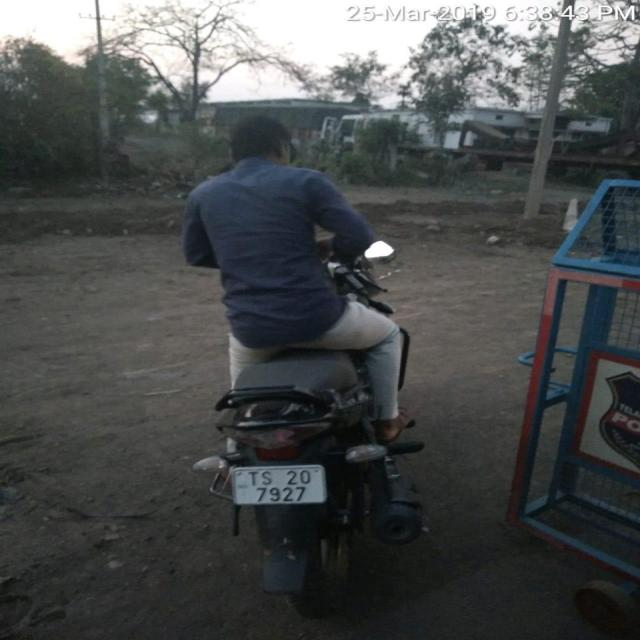

In [69]:
from IPython.display import Image, display
import os

test_path = "/content/drive/MyDrive/hackathon_assets/test_images"

img_name = os.listdir(test_path)[7]

print(img_name)

display(Image(os.path.join(test_path, img_name)))

In [55]:
!pip install easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 26.8 MB/s eta 0:00:00


In [56]:
import easyocr

reader = easyocr.Reader(['en'])
print("EasyOCR Loaded Successfully")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR Loaded Successfully


In [70]:
result = reader.readtext(
    os.path.join(test_path, img_name)
)

for item in result:
    print(item[1])

25-Mlar-Zok 9)
3:
TS 20
7927


In [ ]:
import shutil

best_pt = RUNS_DIR / "train-3" / "weights" / "best.pt"
if best_pt.exists():
    shutil.copy2(best_pt, BEST_MODEL_PATH)
    print("Copied model to:", BEST_MODEL_PATH)
else:
    print("Best model not found at:", best_pt)